# EDA — CICIDS2017 depurado (pre-OE1: estabilidad del espacio latente)

**Contexto:** monografía *"Caracterización de la Geometría del Espacio Latente
Probabilístico de un VAE para la Detección de Intrusiones"*. Este notebook es el EDA de
preparación, previo a **OE1** (Semanas 1–2 del cronograma), sobre el dataset CICIDS2017
depurado ([Engelen, Rimmer & Joosen, 2021](https://intrusion-detection.distrinet-research.be/WTMC2021/)).

Complementa a `00_raw_data_eda.ipynb` (exploración cruda general) con foco puesto en las
decisiones que alimentan directamente el pipeline de preprocesamiento
(`vae_nids.data.pipeline`) y el diseño del encoder/decoder (arquitectura actual:
Dense-32 → latente-8, x ∈ R^78, ver §6.2 de la monografía):

1. Carga de datos
2. Perfilado básico (nulos/infinitos, distribución de clases, desbalance benigno/malicioso)
3. Chequeo de fuga de datos (Engelen et al.)
4. Distribuciones de features y matriz de correlación
5. Preparación para partición 70/15/15 + escalado sin fuga (funciones listas, **sin ejecutar** el split aún)
6. Resumen de hallazgos

**Kernel:** mismo `.venv` del proyecto (`vae_nids` está instalado en modo editable, así
que `import vae_nids` funciona directo).

**Nota de diseño:** donde el pipeline de producción (`src/vae_nids/data/pipeline.py`) ya
resuelve algo — taxonomía de labels, split estratificado, escalado sin fuga — este
notebook **importa y reutiliza esas mismas funciones** en vez de duplicar la lógica, para
que EDA y pipeline nunca diverjan (este mismo preprocesamiento se reutiliza en OE1–OE4).

In [1]:
from pathlib import Path
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from vae_nids import config as cfg
from vae_nids.data import pipeline as dp

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

np.random.seed(cfg.RANDOM_SEED)

## 1. Carga de datos

Ajusta `N_ROWS_PER_DAY` a un entero (p. ej. `300_000`) si tu máquina no aguanta cargar
los ~1.1 GB completos de una sola vez.

A diferencia de `pipeline.load_and_merge` (que descarta `Flow ID`/IPs/`Timestamp`/puertos
y castea a `float32` al vuelo para mantener bajo el pico de memoria), aquí conservamos
**todas** las columnas porque la Sección 3 (chequeo de fuga) necesita poder inspeccionarlas
antes de decidir excluirlas.

In [2]:
def load_dataset(nrows_per_day: int | None = None) -> pd.DataFrame:
    """Carga y concatena los 5 CSV crudos de `cfg.DATA_DIR`, conservando TODAS las
    columnas (a diferencia de `pipeline.load_and_merge`, que descarta identificadores
    y puertos al vuelo). Pensada para EDA; el entrenamiento real usa `pipeline.main()`.
    """
    frames = []
    for fname in cfg.CSV_FILES:
        fpath = cfg.DATA_DIR / fname
        if not fpath.exists():
            raise FileNotFoundError(
                f"No encuentro {fpath}. Ajusta cfg.DATA_DIR si tu copia vive en otro lugar."
            )
        day = fname.split("-")[0]
        df_day = pd.read_csv(fpath, nrows=nrows_per_day, low_memory=False)
        df_day.columns = df_day.columns.str.strip()
        df_day["Day"] = day
        frames.append(df_day)
        print(f"[load] {fname:30s} -> {len(df_day):>10,} filas")

    df = pd.concat(frames, ignore_index=True)
    del frames
    print(f"\n[load] total: {len(df):,} filas x {df.shape[1]} columnas")
    return df


N_ROWS_PER_DAY = None  # None = cargar todo; o un entero para muestrear rápido
df = load_dataset(N_ROWS_PER_DAY)

[load] Monday-WorkingHours.csv        ->    371,749 filas
[load] Tuesday-WorkingHours.csv       ->    322,003 filas
[load] Wednesday-WorkingHours.csv     ->    496,779 filas
[load] Thursday-WorkingHours.csv      ->    362,368 filas
[load] Friday-WorkingHours.csv        ->    547,915 filas

[load] total: 2,100,814 filas x 85 columnas


In [3]:
print("shape:", df.shape)
df.dtypes.value_counts()

shape: (2100814, 85)


float64    45
int64      34
str         6
Name: count, dtype: int64

In [4]:
list(df.columns)

['Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Total Length of Fwd Packet',
 'Total Length of Bwd Packet',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'R

## 2. Perfilado básico

### 2.1 Nulos e infinitos

In [5]:
def count_nulls_infs(df: pd.DataFrame, cols=None) -> pd.DataFrame:
    """Cuenta nulos e infinitos por columna numérica. Relevante: Engelen et al. (2021)
    reportan artefactos de división por cero en tasas de paquetes/tiempo (p. ej.
    `Flow Bytes/s`, `Flow Packets/s`, `Flow IAT *`).
    """
    cols = cols if cols is not None else df.select_dtypes(include=[np.number]).columns
    n_inf = np.isinf(df[cols]).sum()
    n_null = df[cols].isna().sum()
    out = pd.DataFrame({"n_inf": n_inf, "n_null": n_null})
    out["pct_affected"] = (out["n_inf"] + out["n_null"]) / len(df)
    return out[(out["n_inf"] > 0) | (out["n_null"] > 0)].sort_values(
        "pct_affected", ascending=False
    )


numeric_cols = df.select_dtypes(include=[np.number]).columns
null_inf_report = count_nulls_infs(df, numeric_cols)
null_inf_report

,n_inf,n_null,pct_affected
Flow Bytes/s,191,602,0.000377
Flow Packets/s,793,0,0.000377
Flow IAT Mean,0,252,0.000120
Flow IAT Std,0,252,0.000120
Flow IAT Max,0,252,0.000120
Flow IAT Min,0,252,0.000120


Reutilizamos `pipeline.sanitize` (en vez de reimplementar el filtro) para medir de una
vez cuántas filas se perderían en el paso de sanitización real.

In [6]:
_sanitized_preview = dp.sanitize(df.copy())
n_dropped = len(df) - len(_sanitized_preview)
print(f"[sanitize] filas descartadas: {n_dropped:,} ({n_dropped / len(df):.4%})")
del _sanitized_preview

[sanitize] eliminadas 793 filas (0.0377%) por nulos/infinitos
[sanitize] filas descartadas: 793 (0.0377%)


### 2.2 Distribución de clases: benigno vs. familia de ataque

In [7]:
df = dp.build_label_taxonomy(df)  # agrega is_benign / is_attempted / attack_family

label_counts = df[cfg.LABEL_COL].value_counts()
family_counts = df["attack_family"].value_counts()

class_table = pd.DataFrame({
    "count": family_counts,
    "pct_%": (family_counts / len(df) * 100).round(4),
})
class_table

,count,pct_%
attack_family,,
BENIGN,1657693,78.9072
PortScan,159151,7.5757
DoS Hulk,159062,7.5714
DDoS,95123,4.5279
DoS GoldenEye,7647,0.3640
DoS slowloris,5732,0.2728
DoS Slowhttptest,5111,0.2433
FTP-Patator,3984,0.1896
SSH-Patator,2988,0.1422


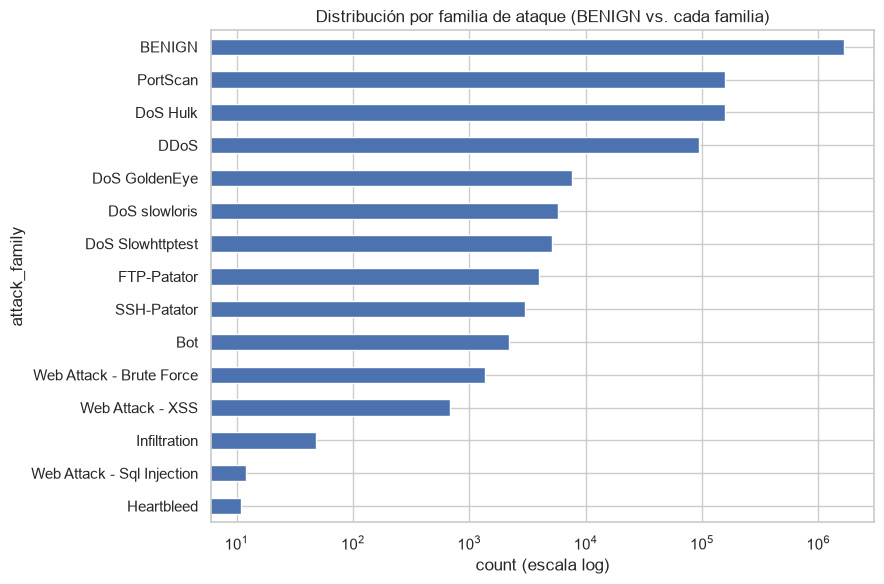

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
family_counts.sort_values().plot(kind="barh", ax=ax, logx=True)
ax.set_xlabel("count (escala log)")
ax.set_title("Distribución por familia de ataque (BENIGN vs. cada familia)")
plt.tight_layout()
plt.show()

### 2.3 Desbalance benigno/malicioso

In [9]:
n_benign = int(df["is_benign"].sum())
n_attack = int((~df["is_benign"]).sum())
print(f"Benigno:    {n_benign:>10,} ({n_benign / len(df):.2%})")
print(f"Malicioso:  {n_attack:>10,} ({n_attack / len(df):.2%})")
print(f"Ratio benigno:malicioso = {n_benign / n_attack:.1f} : 1")

Benigno:     1,657,693 (78.91%)
Malicioso:     443,121 (21.09%)
Ratio benigno:malicioso = 3.7 : 1


## 3. Chequeo de fuga de datos (Engelen et al., 2021)

Engelen et al. documentan que CICFlowMeter deja artefactos de la infraestructura de
simulación (TTL fijo, patrones de temporización artificiales) que un modelo puede
memorizar en vez de aprender comportamiento de ataque genuino. Dos chequeos:

1. Columnas constantes o cuasi-constantes → candidatas a ese tipo de artefacto.
2. Columnas identificadoras (IP/puerto/timestamp) que ya se excluyen por diseño en
   `cfg.IDENTIFIER_COLS` / `cfg.PORT_COLS` — aquí verificamos *por qué* tiene sentido
   excluirlas.

In [10]:
def find_constant_columns(
    df: pd.DataFrame, cols=None, near_constant_thresh: float = 0.99
) -> pd.DataFrame:
    """Detecta columnas constantes o cuasi-constantes: candidatas a artefactos de
    simulación (TTL fijo, banderas siempre en el mismo estado, etc.).
    `near_constant_thresh`: si el valor más frecuente cubre >= este umbral, se marca
    como cuasi-constante.
    """
    cols = cols if cols is not None else df.columns
    rows = []
    for c in cols:
        vc = df[c].value_counts(normalize=True, dropna=False)
        top_val, top_frac = vc.index[0], float(vc.iloc[0])
        rows.append({
            "column": c,
            "n_unique": df[c].nunique(dropna=False),
            "top_value": top_val,
            "top_value_frac": top_frac,
            "constant": df[c].nunique(dropna=False) == 1,
            "near_constant": top_frac >= near_constant_thresh,
        })
    out = pd.DataFrame(rows).set_index("column")
    return out[out["constant"] | out["near_constant"]].sort_values(
        "top_value_frac", ascending=False
    )


non_feature_cols = ["Day", cfg.LABEL_COL, "is_benign", "is_attempted", "attack_family"]
feature_candidates = [c for c in df.columns if c not in non_feature_cols]

constant_report = find_constant_columns(df, feature_candidates, near_constant_thresh=0.99)
constant_report

,n_unique,top_value,top_value_frac,constant,near_constant
column,,,,,
Bwd URG Flags,2,0,1.000000,False,True
Fwd URG Flags,5,0,0.999956,False,True
URG Flag Count,5,0,0.999955,False,True
Subflow Bwd Packets,2,0,0.999923,False,True
ECE Flag Count,5,0,0.999673,False,True
CWR Flag Count,9,0,0.999636,False,True


In [11]:
print("Columnas excluidas por diseño (fuga de identidad, ver cfg.IDENTIFIER_COLS / cfg.PORT_COLS):")
for c in cfg.IDENTIFIER_COLS + cfg.PORT_COLS:
    if c in df.columns:
        print(f"  {c:12s} {df[c].nunique():>10,} valores únicos")

Columnas excluidas por diseño (fuga de identidad, ver cfg.IDENTIFIER_COLS / cfg.PORT_COLS):
  Flow ID       1,085,372 valores únicos
  Src IP               48 valores únicos
  Dst IP           19,045 valores únicos
  Timestamp       100,918 valores únicos
  Src Port         64,639 valores únicos
  Dst Port          5,434 valores únicos


Chequeo puntual: si las IPs de atacante/víctima son ~fijas por familia (como documenta
el README), cada familia de ataque debería tener muy pocas IPs origen distintas — lo que
confirma que dejarlas como feature sería fuga de identidad, no señal de comportamiento.

In [12]:
if "Src IP" in df.columns:
    ip_by_family = (
        df.loc[~df["is_benign"]]
        .groupby("attack_family")["Src IP"]
        .nunique()
        .sort_values(ascending=False)
    )
    print("IPs origen únicas por familia de ataque (bajo == IP ~fija -> justifica excluirla):")
    ip_by_family

IPs origen únicas por familia de ataque (bajo == IP ~fija -> justifica excluirla):


## 4. Distribuciones de features

### 4.1 Histogramas benigno vs. malicioso

[sanitize] eliminadas 793 filas (0.0377%) por nulos/infinitos


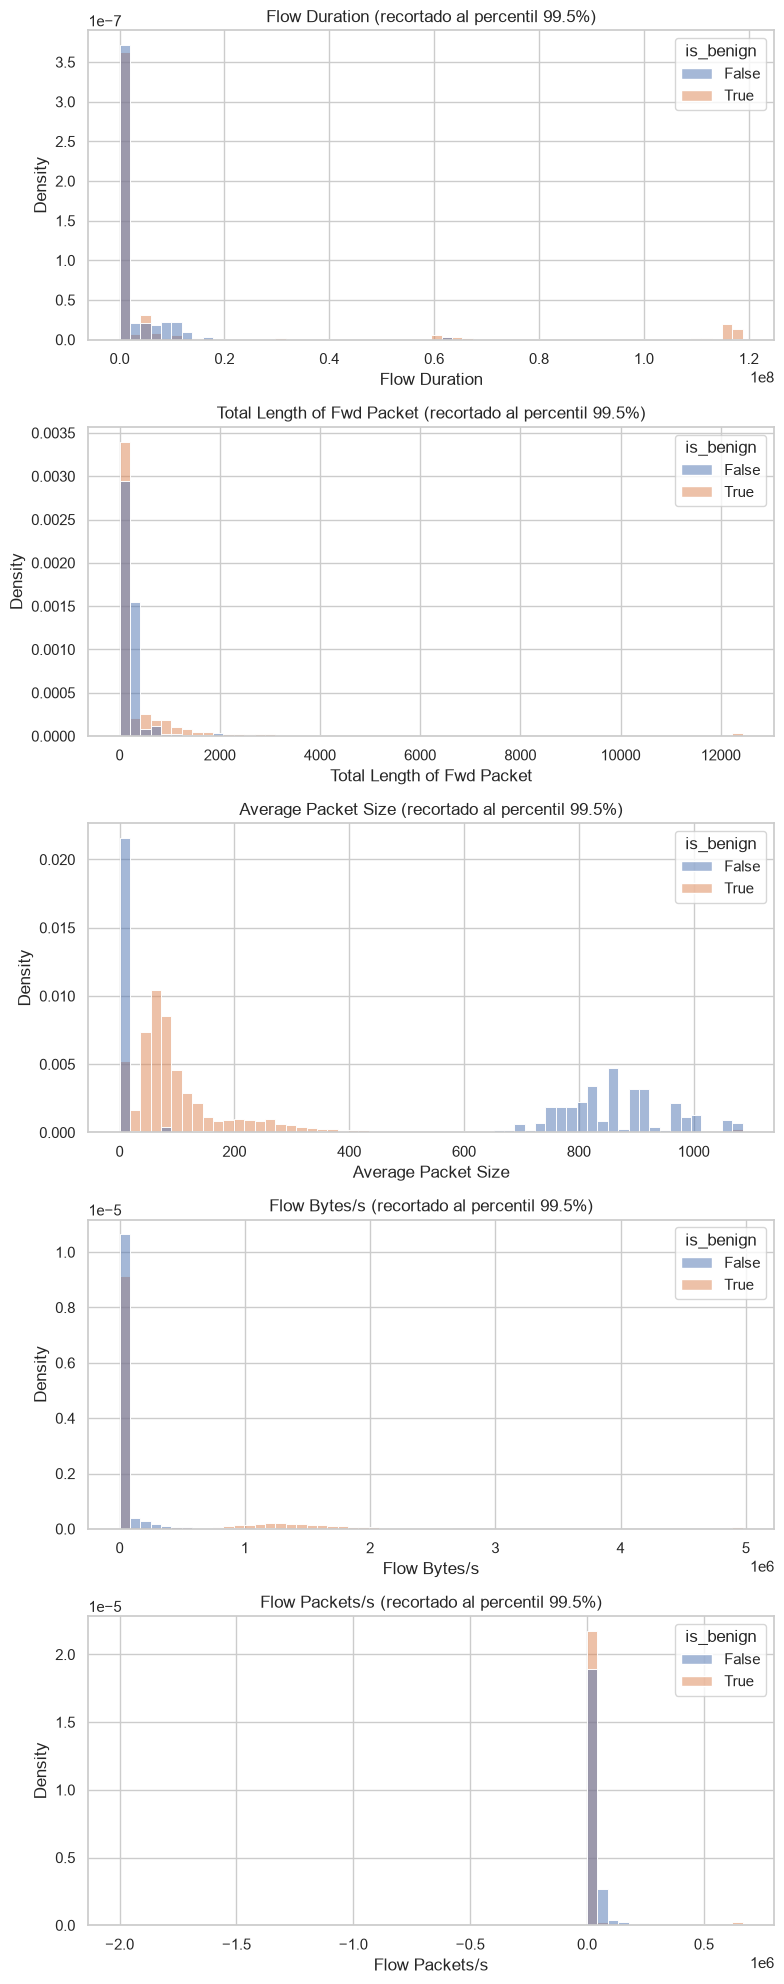

In [13]:
def plot_hist_by_class(
    df: pd.DataFrame,
    col: str,
    class_col: str = "is_benign",
    bins: int = 60,
    clip_quantile: float = 0.995,
    ax=None,
):
    """Histograma de `col` separado por clase (benigno/malicioso por defecto).
    Recorta al percentil `clip_quantile` para que outliers extremos (típicos en
    bytes/s, duración de flujo) no aplasten la escala visual.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    upper = df[col].quantile(clip_quantile)
    data = df[[col, class_col]].copy()
    data[col] = data[col].clip(upper=upper)
    sns.histplot(
        data=data, x=col, hue=class_col, bins=bins,
        stat="density", common_norm=False, ax=ax,
    )
    ax.set_title(f"{col} (recortado al percentil {clip_quantile:.1%})")
    return ax


# Requiere inf/nan ya fuera (ver Sección 2.1) para no distorsionar cuantiles/histogramas.
df_clean = dp.sanitize(df.copy())

key_features = [
    "Flow Duration",
    "Total Length of Fwd Packet",
    "Average Packet Size",
    "Flow Bytes/s",
    "Flow Packets/s",
]
key_features = [c for c in key_features if c in df_clean.columns]

fig, axes = plt.subplots(len(key_features), 1, figsize=(8, 4 * len(key_features)))
for ax, col in zip(np.atleast_1d(axes), key_features):
    plot_hist_by_class(df_clean, col, ax=ax)
plt.tight_layout()
plt.show()

### 4.2 Matriz de correlación

Se usa `pipeline.get_feature_columns` (el mismo selector que usará el pipeline real)
para operar exactamente sobre las columnas que verá el encoder, en vez de recalcular la
lista a mano.

[features] 77 columnas seleccionadas como features (verifica que coincida con tu arquitectura, ej. x ∈ R^78)


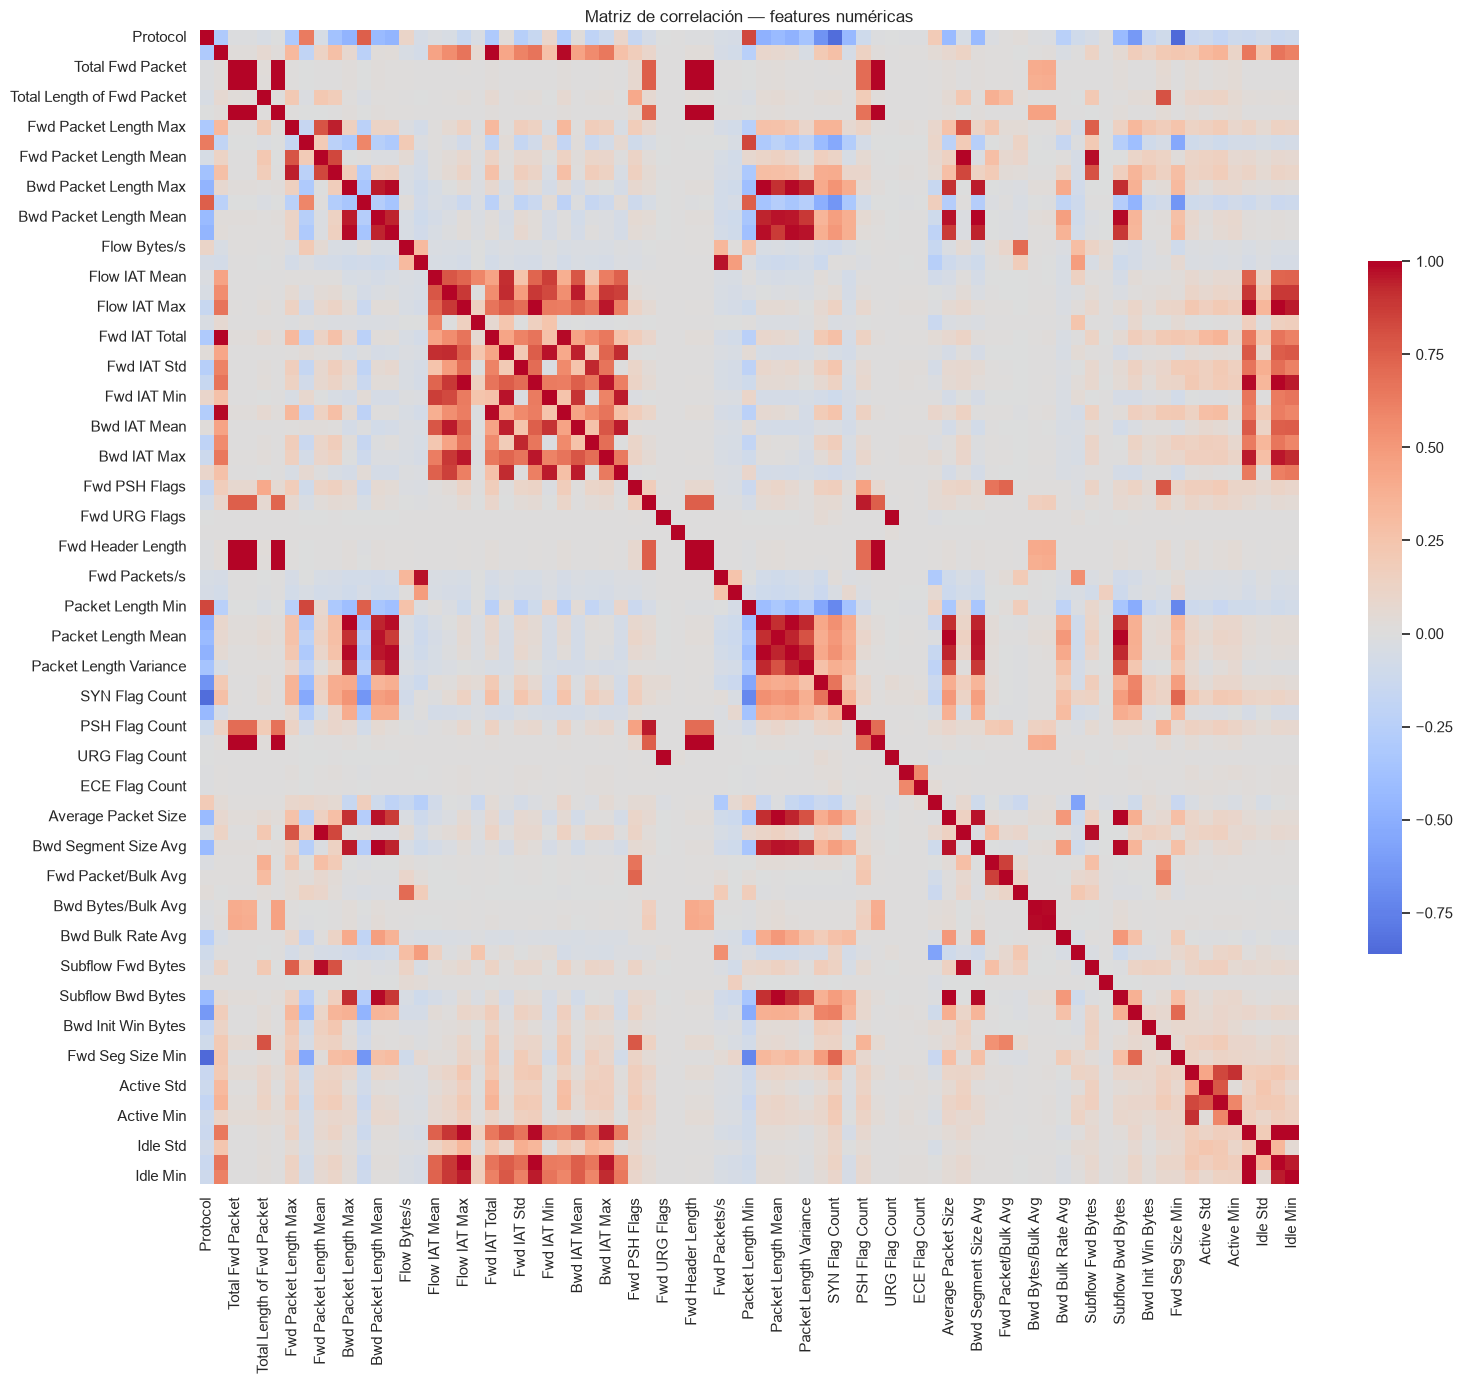

In [14]:
feature_cols = dp.get_feature_columns(df_clean)
corr = df_clean[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title("Matriz de correlación — features numéricas")
plt.tight_layout()
plt.show()

In [15]:
def find_correlated_pairs(corr: pd.DataFrame, threshold: float = 0.9) -> pd.DataFrame:
    """Pares de features con |correlación| >= threshold: redundancia candidata a
    recorte antes de fijar la dimensión de entrada del encoder (actualmente R^78).
    """
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    pairs = (
        corr.where(mask)
        .stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    pairs = pairs[pairs["corr"].abs() >= threshold]
    return pairs.sort_values("corr", key=np.abs, ascending=False).reset_index(drop=True)


high_corr_pairs = find_correlated_pairs(corr, threshold=0.9)
print(f"{len(high_corr_pairs)} pares con |r| >= 0.9 (de {len(feature_cols)} features, "
      f"{len(feature_cols) * (len(feature_cols) - 1) // 2} pares posibles)")
high_corr_pairs

89 pares con |r| >= 0.9 (de 77 features, 2926 pares posibles)


,feature_a,feature_b,corr
0,Bwd Packet Length Mean,Bwd Segment Size Avg,1.000000
1,Packet Length Mean,Average Packet Size,1.000000
2,Fwd Packet Length Mean,Fwd Segment Size Avg,1.000000
3,Total Bwd packets,ACK Flag Count,0.999825
4,Total Fwd Packet,ACK Flag Count,0.999685
...,...,...,...
84,Bwd Packet Length Max,Average Packet Size,0.908108
85,Bwd Packet Length Max,Packet Length Mean,0.908108
86,Active Mean,Active Min,0.907055
87,Packet Length Max,Subflow Bwd Bytes,0.905627


## 5. Preparación para partición (funciones listas, sin ejecutar)

La partición estratificada 70/15/15 sobre el subconjunto benigno y el `MinMaxScaler`
ajustado solo con el split de entrenamiento (§6.3 de la monografía) **ya están
implementados** en `src/vae_nids/data/pipeline.py` como `split_benign` y
`scale_no_leakage` — no se reimplementan aquí para evitar que EDA y pipeline diverjan.

Esta sección solo confirma que las funciones están listas e importables; **no se ejecuta
el split sobre el dataset completo en este notebook** (eso corresponde a
`python -m vae_nids.data.pipeline`, ver README, una vez cerradas las decisiones de la
Sección 6 — p. ej. qué columnas cuasi-constantes o redundantes excluir antes de fijar la
lista definitiva de features).

In [16]:
print(inspect.getsource(dp.split_benign))

def split_benign(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """70/15/15 estratificado por día, SOLO sobre tráfico benigno."""
    benign = df[df["is_benign"]].reset_index(drop=True)
    strat = benign["Day"] if cfg.STRATIFY_BENIGN_BY_DAY else None

    train, temp = train_test_split(
        benign,
        train_size=cfg.TRAIN_FRAC,
        random_state=cfg.RANDOM_SEED,
        stratify=strat,
    )
    val_size_rel = cfg.VAL_FRAC / (cfg.VAL_FRAC + cfg.TEST_FRAC)
    strat_temp = temp["Day"] if cfg.STRATIFY_BENIGN_BY_DAY else None
    val, test = train_test_split(
        temp,
        train_size=val_size_rel,
        random_state=cfg.RANDOM_SEED,
        stratify=strat_temp,
    )
    print(f"[split] benign train={len(train):,} val={len(val):,} test={len(test):,}")
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)



In [17]:
print(inspect.getsource(dp.scale_no_leakage))

def scale_no_leakage(
    train: pd.DataFrame, val: pd.DataFrame, test: pd.DataFrame,
    attacks: pd.DataFrame, feature_cols: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, MinMaxScaler]:
    """Ajusta MinMaxScaler EXCLUSIVAMENTE sobre train y lo aplica de forma
    estática a val/test/attacks, evitando fuga de datos.

    Transforma in-place (sin .copy() de los DataFrames completos) para
    mantener el pico de memoria bajo.
    """
    scaler = MinMaxScaler()
    train[feature_cols] = scaler.fit_transform(train[feature_cols]).astype("float32")
    val[feature_cols] = scaler.transform(val[feature_cols]).astype("float32")
    test[feature_cols] = scaler.transform(test[feature_cols]).astype("float32")
    attacks[feature_cols] = scaler.transform(attacks[feature_cols]).astype("float32")

    return train, val, test, attacks, scaler



In [18]:
print("cfg.TRAIN_FRAC / VAL_FRAC / TEST_FRAC:", cfg.TRAIN_FRAC, cfg.VAL_FRAC, cfg.TEST_FRAC)
print("cfg.STRATIFY_BENIGN_BY_DAY:", cfg.STRATIFY_BENIGN_BY_DAY)
print("cfg.RANDOM_SEED:", cfg.RANDOM_SEED)
print()
print("Para generar train/val/test/attacks + scaler.joblib, ejecutar desde la raíz del repo:")
print("    python -m vae_nids.data.pipeline")

cfg.TRAIN_FRAC / VAL_FRAC / TEST_FRAC: 0.7 0.15 0.15
cfg.STRATIFY_BENIGN_BY_DAY: True
cfg.RANDOM_SEED: 42

Para generar train/val/test/attacks + scaler.joblib, ejecutar desde la raíz del repo:
    python -m vae_nids.data.pipeline


## 6. Resumen de hallazgos

_(completar a mano tras correr las secciones de arriba sobre el dataset completo)_

- **% de filas descartadas en sanitización** (Sección 2.1): `<completar>` — comparar
  contra el ~0.04% documentado en el README para el dataset depurado.
- **Features candidatas a eliminar** (Sección 3, constantes/cuasi-constantes): `<listar
  columnas de `constant_report`>`.
- **Features redundantes** (Sección 4.2, `high_corr_pairs`): `<listar pares con |r| ≥ 0.9
  y decidir cuáles recortar>`.
- **Desbalance benigno/malicioso** (Sección 2.3): `<completar ratio>` — confirma la
  necesidad del paradigma one-class descrito en la Sección 1 de la monografía.
- **Hallazgos que afectan el diseño del encoder/decoder**: dimensión de entrada del
  encoder = **TBD**, ver Sección 7.8 — depende de la revisión metodológica de los
  clusters candidatos de la Sección 7.4; no se fija R^78 ni ningún otro número aquí
  todavía.
- **Otras anomalías / decisiones pendientes para OE1:** `<completar>`.

### 4.3 Clustering de features mutuamente correlacionadas

Los pares con |r| ≥ 0.9 de la sección anterior no son problemas de redundancia
independientes entre sí: si A-B y B-C superan el umbral, A, B y C forman un mismo
grupo redundante aunque A-C no lo haya cruzado directamente. Agrupamos los pares en
componentes conexas del grafo de correlación (union-find sobre `feature_a`/`feature_b`;
sin depender de `networkx`, que no es una dependencia declarada del proyecto) para ver
cuántas features **distintas** quedan realmente involucradas — la base para decidir con
datos, y no a ojo, cuántas de las 77 features se pueden recortar antes de fijar la
dimensión de entrada del encoder, y de paso resolver el pendiente **77 vs. 78**
(`len(feature_cols)` tras excluir `IDENTIFIER_COLS`/`PORT_COLS` vs. el R^78 de la
Sección 6.2 de la monografía).

In [19]:
def cluster_correlated_features(pairs: pd.DataFrame) -> list[set[str]]:
    """Agrupa pares (feature_a, feature_b) en clusters de features mutuamente
    correlacionadas vía union-find sobre componentes conexas: A-B y B-C correlacionados
    implica que A, B, C caen en el mismo cluster, aunque A-C no cruce el umbral
    directamente. Devuelve los clusters ordenados de mayor a menor tamaño.
    """
    parent: dict[str, str] = {}

    def find(x: str) -> str:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: str, b: str) -> None:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for a, b in pairs[["feature_a", "feature_b"]].itertuples(index=False, name=None):
        parent.setdefault(a, a)
        parent.setdefault(b, b)
        union(a, b)

    groups: dict[str, set[str]] = {}
    for node in parent:
        groups.setdefault(find(node), set()).add(node)
    return sorted(groups.values(), key=len, reverse=True)


clusters = cluster_correlated_features(high_corr_pairs)

cluster_summary = pd.DataFrame([
    {"cluster_id": i, "n_features": len(c), "features": ", ".join(sorted(c))}
    for i, c in enumerate(clusters)
])
cluster_summary

,cluster_id,n_features,features
0,0,10,"Average Packet Size, Bwd Packet Length Max, Bw..."
1,1,6,"ACK Flag Count, Bwd Header Length, Fwd Header ..."
2,2,6,"Bwd IAT Max, Flow IAT Max, Fwd IAT Max, Idle M..."
3,3,6,"Bwd IAT Mean, Bwd IAT Min, Flow IAT Mean, Flow..."
4,4,3,"Fwd Packet Length Mean, Fwd Segment Size Avg, ..."
5,5,3,"Bwd IAT Total, Flow Duration, Fwd IAT Total"
6,6,2,"Fwd URG Flags, URG Flag Count"
7,7,2,"Bwd Bytes/Bulk Avg, Bwd Packet/Bulk Avg"
8,8,2,"Flow Packets/s, Fwd Packets/s"
9,9,2,"Bwd PSH Flags, PSH Flag Count"


In [20]:
n_involved = sum(len(c) for c in clusters)
n_trimmable = sum(len(c) - 1 for c in clusters)  # recorte si se deja 1 representante por cluster

print(f"Clusters de features mutuamente correlacionadas (|r| >= 0.9): {len(clusters)}")
print(f"Features distintas involucradas: {n_involved} de {len(feature_cols)} features totales")
print(f"Features recortables (dejando 1 representante por cluster): {n_trimmable}")
print(f"Dimensión de entrada resultante si se recorta: {len(feature_cols) - n_trimmable} "
      f"(features actuales tras excluir IDENTIFIER_COLS/PORT_COLS: {len(feature_cols)}; "
      f"R^78 en la arquitectura de la monografía, Sección 6.2)")

Clusters de features mutuamente correlacionadas (|r| >= 0.9): 13
Features distintas involucradas: 48 de 77 features totales
Features recortables (dejando 1 representante por cluster): 35
Dimensión de entrada resultante si se recorta: 42 (features actuales tras excluir IDENTIFIER_COLS/PORT_COLS: 77; R^78 en la arquitectura de la monografía, Sección 6.2)


## 7. Dataset final limpio y anotado

Cierra el ciclo de las Secciones 3–4: decide qué hacer con cada hallazgo de fuga o
redundancia, sin recortar features de forma automática salvo los duplicados exactos
(r = 1.0). El resto —columnas near-constant sin patrón claro y los clusters con r entre
0.9 y 0.99— queda **documentado como candidato, no descartado**, porque la correlación de
la Sección 4.2 se calculó sobre benigno+malicioso mezclado: si una familia de ataque
necesita justo esa feature para separarse del núcleo benigno, recortarla ahora sesgaría
OE2 antes de siquiera llegar a esa pregunta.

**No se reejecuta la Sección 5** (split/scale) en esta sección — sigue pendiente hasta
cerrar esta decisión.

### 7.1 Columnas near-constant vs. familia de ataque

Para cada columna near-constante de la Sección 3 (ya restringida a `feature_cols`, es
decir, excluyendo IDs/puertos que se excluyen por otra razón), miramos en qué familia de
ataque se concentra el valor NO dominante. Regla automática:

- **conservar**: el valor no-dominante se concentra > 90 % en una sola familia → la
  columna distingue esa familia del resto, es informativa.
- **eliminable**: el valor no-dominante se dispersa entre ≥ 3 familias sin patrón → ruido,
  candidata real a recorte.
- **revisar**: cualquier caso intermedio → se conserva por defecto hasta revisión manual
  (no se asume redundancia sin evidencia).

In [21]:
near_constant_cols = [c for c in constant_report.index if c in feature_cols]
print(f"Columnas near-constant dentro de feature_cols: {len(near_constant_cols)}")


def near_constant_family_breakdown(df: pd.DataFrame, col: str, top_value) -> pd.Series:
    """% de las filas con valor != top_value (el valor dominante de `col`), desglosado
    por attack_family -- el crosstab base para decidir si la columna es informativa o
    solo ruido.
    """
    mask = df[col] != top_value
    return df.loc[mask, "attack_family"].value_counts(normalize=True).rename(col)


breakdown_table = pd.concat(
    [
        near_constant_family_breakdown(df_clean, c, constant_report.loc[c, "top_value"])
        for c in near_constant_cols
    ],
    axis=1,
).fillna(0.0)
breakdown_table

Columnas near-constant dentro de feature_cols: 6


,Bwd URG Flags,Fwd URG Flags,URG Flag Count,Subflow Bwd Packets,ECE Flag Count,CWR Flag Count
attack_family,,,,,,
BENIGN,1.0,1.0,1.0,0.960938,1.0,1.0
DoS Slowhttptest,0.0,0.0,0.0,0.031250,0.0,0.0
DoS slowloris,0.0,0.0,0.0,0.007812,0.0,0.0


In [22]:
def decide_near_constant(
    col: str, family_pct: pd.Series, n_non_dominant: int,
    dominance_thresh: float = 0.90, min_families_for_disperse: int = 3,
) -> dict:
    """Decide si una columna near-constante es informativa ('conservar'), ruido
    ('eliminable') o requiere revisión manual ('revisar'), según qué tan concentrado
    esté su valor no-dominante en una única familia de ataque.
    """
    if n_non_dominant == 0:
        return {
            "column": col, "n_non_dominant": 0, "decision": "eliminable",
            "reason": "constante exacta: 0 filas con valor distinto al dominante",
            "top_family": None, "top_family_pct": None, "n_families_involved": 0,
        }

    present = family_pct[family_pct > 0].sort_values(ascending=False)
    top_family, top_family_pct = present.index[0], float(present.iloc[0])
    n_families_involved = int(len(present))

    if top_family_pct > dominance_thresh:
        decision = "conservar"
        reason = f"{top_family_pct:.1%} del valor no-dominante cae en '{top_family}' -> columna informativa"
    elif n_families_involved >= min_families_for_disperse:
        decision = "eliminable"
        reason = f"valor no-dominante disperso entre {n_families_involved} familias sin patrón claro"
    else:
        decision = "revisar"
        reason = f"caso intermedio: '{top_family}' cubre {top_family_pct:.1%} en {n_families_involved} familias"

    return {
        "column": col, "n_non_dominant": n_non_dominant, "decision": decision, "reason": reason,
        "top_family": top_family, "top_family_pct": top_family_pct, "n_families_involved": n_families_involved,
    }


near_constant_decisions = pd.DataFrame([
    decide_near_constant(
        c,
        breakdown_table[c],
        n_non_dominant=int((df_clean[c] != constant_report.loc[c, "top_value"]).sum()),
    )
    for c in near_constant_cols
]).set_index("column")
near_constant_decisions

,n_non_dominant,decision,reason,top_family,top_family_pct,n_families_involved
column,,,,,,
Bwd URG Flags,1,conservar,100.0% del valor no-dominante cae en 'BENIGN' ...,BENIGN,1.000000,1
Fwd URG Flags,93,conservar,100.0% del valor no-dominante cae en 'BENIGN' ...,BENIGN,1.000000,1
URG Flag Count,94,conservar,100.0% del valor no-dominante cae en 'BENIGN' ...,BENIGN,1.000000,1
Subflow Bwd Packets,128,conservar,96.1% del valor no-dominante cae en 'BENIGN' -...,BENIGN,0.960938,3
ECE Flag Count,686,conservar,100.0% del valor no-dominante cae en 'BENIGN' ...,BENIGN,1.000000,1
CWR Flag Count,764,conservar,100.0% del valor no-dominante cae en 'BENIGN' ...,BENIGN,1.000000,1


### 7.2 Bug en `pipeline.sanitize`: tasas negativas no se atrapan

`pipeline.sanitize` solo reemplaza `inf`/`-inf` por `NaN` y descarta nulos (Sección 2.1),
pero **no valida rango**: `Flow Bytes/s`, `Flow Packets/s`, `Fwd Packets/s` y
`Bwd Packets/s` son tasas que nunca deberían ser negativas — un valor negativo es el
mismo tipo de artefacto de división corrupta que documentan Engelen et al., solo que
`sanitize` no lo cubre porque un negativo no es `NaN` ni `inf`. Se documenta aquí como
bug pendiente de reportar/parchear en `pipeline.py`; mientras tanto, se filtra localmente
como un paso adicional después de `sanitize`.

In [23]:
RATE_COLS = [c for c in ["Flow Bytes/s", "Flow Packets/s", "Fwd Packets/s", "Bwd Packets/s"]
             if c in df_clean.columns]


def filter_invalid_rates(df: pd.DataFrame, rate_cols: list[str]) -> tuple[pd.DataFrame, int]:
    """Descarta filas con valores negativos en columnas de tasa (bytes/paquetes por
    segundo), que `pipeline.sanitize` no atrapa por no ser NaN ni inf.
    """
    mask_invalid = (df[rate_cols] < 0).any(axis=1)
    n_dropped = int(mask_invalid.sum())
    return df.loc[~mask_invalid].reset_index(drop=True), n_dropped


df_after_rate_filter, n_dropped_negative_rates = filter_invalid_rates(df_clean, RATE_COLS)
print(f"[filter_invalid_rates] filas con tasas negativas descartadas: {n_dropped_negative_rates:,} "
      f"({n_dropped_negative_rates / len(df_clean):.4%} sobre el subconjunto ya sanitizado) "
      f"-- separado del conteo de nulos/infinitos de la Sección 2.1")

[filter_invalid_rates] filas con tasas negativas descartadas: 31 (0.0015% sobre el subconjunto ya sanitizado) -- separado del conteo de nulos/infinitos de la Sección 2.1


### 7.3 Duplicados exactos (r = 1.0)

De los clusters de la Sección 4.3, los pares con correlación exactamente 1.0 no son
"muy parecidos": son la misma columna calculada dos veces. Esos sí se recortan,
quedándose con el nombre estándar de CICFlowMeter (`... Length Mean`) sobre el alias
(`... Segment Size Avg`, `Average ...`).

In [24]:
exact_dupe_pairs = high_corr_pairs[np.isclose(high_corr_pairs["corr"].abs(), 1.0)]
print(f"Pares con r == 1.0 (duplicados exactos): {len(exact_dupe_pairs)}")


def pick_representative(pair: tuple[str, str]) -> tuple[str, str]:
    """Entre dos columnas duplicadas exactas, conserva la que NO tenga 'avg'/'average'
    en el nombre (alias que duplica una estadística ya presente con el nombre estándar
    de CICFlowMeter, p. ej. 'Bwd Packet Length Mean' sobre 'Bwd Segment Size Avg').
    Devuelve (keep, drop).
    """
    a, b = pair
    a_is_alias = "avg" in a.lower() or "average" in a.lower()
    b_is_alias = "avg" in b.lower() or "average" in b.lower()
    if a_is_alias and not b_is_alias:
        return b, a
    if b_is_alias and not a_is_alias:
        return a, b
    return (a, b) if len(a) <= len(b) else (b, a)


exact_duplicate_drops: dict[str, str] = {}
for _, row in exact_dupe_pairs.iterrows():
    keep, drop = pick_representative((row["feature_a"], row["feature_b"]))
    exact_duplicate_drops[drop] = f"duplicado exacto de '{keep}', r={row['corr']:.4f}"

exact_duplicate_drops

Pares con r == 1.0 (duplicados exactos): 3


{'Bwd Segment Size Avg': "duplicado exacto de 'Bwd Packet Length Mean', r=1.0000",
 'Average Packet Size': "duplicado exacto de 'Packet Length Mean', r=1.0000",
 'Fwd Segment Size Avg': "duplicado exacto de 'Fwd Packet Length Mean', r=1.0000"}

### 7.4 Clusters candidatos para revisión metodológica (pendiente, no se recortan)

Los clusters restantes (r entre 0.9 y 0.99, descontando los ya resueltos como duplicado
exacto en 7.3) **no se eliminan aquí**. Quedan como tabla de candidatos, con el rango de
correlación interno (mínimo/máximo entre TODOS los pares del cluster, no solo los que
cruzaron el umbral directamente) para que la revisión en OE2 decida, cruzándolos con
AUC-ROC por familia, si de verdad son redundancia o si alguna familia de ataque depende
de esa feature en particular para separarse del núcleo benigno.

In [25]:
def cluster_corr_range(cluster: set[str], corr: pd.DataFrame) -> tuple[float, float]:
    """Correlación mínima y máxima (valor absoluto) entre TODOS los pares de features
    dentro de un cluster, no solo los pares que cruzaron el umbral de 0.9 directamente.
    """
    cols = sorted(cluster)
    sub = corr.loc[cols, cols].abs()
    off_diag = sub.where(~np.eye(len(cols), dtype=bool))
    return float(off_diag.min().min()), float(off_diag.max().max())


resolved_dup_sets = [
    set(pair) for pair in exact_dupe_pairs[["feature_a", "feature_b"]].itertuples(index=False, name=None)
]

candidate_clusters = []
for i, cl in enumerate(clusters):
    if cl in resolved_dup_sets:
        continue
    lo, hi = cluster_corr_range(cl, corr)
    candidate_clusters.append({
        "cluster_id": i,
        "n_features": len(cl),
        "features": ", ".join(sorted(cl)),
        "corr_min_abs": lo,
        "corr_max_abs": hi,
    })

candidate_clusters_df = pd.DataFrame(candidate_clusters)
print(f"Clusters candidatos pendientes de revisión (excluyendo los "
      f"{len(resolved_dup_sets)} ya resueltos como duplicado exacto): {len(candidate_clusters_df)}")
candidate_clusters_df

Clusters candidatos pendientes de revisión (excluyendo los 3 ya resueltos como duplicado exacto): 13


,cluster_id,n_features,features,corr_min_abs,corr_max_abs
0,0,10,"Average Packet Size, Bwd Packet Length Max, Bw...",0.801612,1.000000
1,1,6,"ACK Flag Count, Bwd Header Length, Fwd Header ...",0.993853,0.999825
2,2,6,"Bwd IAT Max, Flow IAT Max, Fwd IAT Max, Idle M...",0.927197,0.998542
3,3,6,"Bwd IAT Mean, Bwd IAT Min, Flow IAT Mean, Flow...",0.741382,0.966943
4,4,3,"Fwd Packet Length Mean, Fwd Segment Size Avg, ...",0.974649,1.000000
5,5,3,"Bwd IAT Total, Flow Duration, Fwd IAT Total",0.982383,0.999454
6,6,2,"Fwd URG Flags, URG Flag Count",0.999646,0.999646
7,7,2,"Bwd Bytes/Bulk Avg, Bwd Packet/Bulk Avg",0.978954,0.978954
8,8,2,"Flow Packets/s, Fwd Packets/s",0.967305,0.967305
9,9,2,"Bwd PSH Flags, PSH Flag Count",0.955596,0.955596


### 7.5 Construcción de `df_final`

Orden de aplicación: `sanitize` (nulos/infinitos) → filtro de tasas negativas (7.2) →
exclusión de `IDENTIFIER_COLS`/`PORT_COLS` (ya resuelta por `get_feature_columns`) →
exclusión de near-constant marcadas `eliminable` (7.1) → exclusión de duplicados exactos
(7.3). Los clusters candidatos de 7.4 **no** entran en este recorte.

In [26]:
near_constant_drop = near_constant_decisions[near_constant_decisions["decision"] == "eliminable"].index.tolist()

base_feature_cols = dp.get_feature_columns(df_after_rate_filter)
feature_cols_after_near_constant = [c for c in base_feature_cols if c not in near_constant_drop]
final_feature_cols = [c for c in feature_cols_after_near_constant if c not in exact_duplicate_drops]

df_final = df_after_rate_filter[
    final_feature_cols + [cfg.LABEL_COL, "Day", "is_benign", "is_attempted", "attack_family"]
].copy()

print(f"final_feature_cols: {len(final_feature_cols)}")

[features] 77 columnas seleccionadas como features (verifica que coincida con tu arquitectura, ej. x ∈ R^78)
final_feature_cols: 74


### 7.6 Resumen tipo embudo

In [27]:
print("=== Embudo de preprocesamiento (solo EDA -- la Sección 5/split sigue sin ejecutarse) ===")
print(f"1. Original (crudo + taxonomía):                    {df.shape}")
print(f"2. Tras sanitize (nulos/infinitos, Sección 2.1):    {df_clean.shape}")
print(f"3. Tras filtro de tasas negativas (7.2):             {df_after_rate_filter.shape}  "
      f"(-{n_dropped_negative_rates:,} filas)")
print(f"4. Features tras excluir IDENTIFIER/PORT_COLS:      {len(base_feature_cols)}")
print(f"5. Features tras excluir near-constant eliminables: {len(feature_cols_after_near_constant)}  "
      f"(-{len(near_constant_drop)})")
print(f"6. Features tras excluir duplicados exactos:        {len(final_feature_cols)}  "
      f"(-{len(exact_duplicate_drops)})")
print()
print(f"df_final: {df_final.shape}")
print()
print("Columnas eliminadas y razón:")
for col in near_constant_drop:
    print(f"  - {col}: near-constant sin patrón por familia ({near_constant_decisions.loc[col, 'reason']})")
for col, reason in exact_duplicate_drops.items():
    print(f"  - {col}: {reason}")

=== Embudo de preprocesamiento (solo EDA -- la Sección 5/split sigue sin ejecutarse) ===
1. Original (crudo + taxonomía):                    (2100814, 88)
2. Tras sanitize (nulos/infinitos, Sección 2.1):    (2100021, 88)
3. Tras filtro de tasas negativas (7.2):             (2099990, 88)  (-31 filas)
4. Features tras excluir IDENTIFIER/PORT_COLS:      77
5. Features tras excluir near-constant eliminables: 77  (-0)
6. Features tras excluir duplicados exactos:        74  (-3)

df_final: (2099990, 79)

Columnas eliminadas y razón:
  - Bwd Segment Size Avg: duplicado exacto de 'Bwd Packet Length Mean', r=1.0000
  - Average Packet Size: duplicado exacto de 'Packet Length Mean', r=1.0000
  - Fwd Segment Size Avg: duplicado exacto de 'Fwd Packet Length Mean', r=1.0000


### 7.7 Log de exclusiones (trazabilidad para `pipeline.py`)

Se guarda en `data/processed/eda_exclusion_log.json` para poder actualizar
`get_feature_columns()` en `pipeline.py` sin tener que releer el notebook completo.
Incluye también los clusters pendientes de 7.4, para que quede registro de qué se dejó
sin decidir y por qué.

In [28]:
import json as _json
from datetime import date

exclusion_log = {
    "generated": date.today().isoformat(),
    "source_notebook": "notebooks/eda_cicids2017.ipynb",
    "n_features_before_exclusions": len(base_feature_cols),
    "n_features_after_exclusions": len(final_feature_cols),
    "dropped": {
        "near_constant_no_pattern": [
            {"column": c, "reason": near_constant_decisions.loc[c, "reason"]}
            for c in near_constant_drop
        ],
        "exact_duplicates": [
            {"column": c, "reason": r} for c, r in exact_duplicate_drops.items()
        ],
    },
    "pending_review_clusters": candidate_clusters_df.to_dict(orient="records"),
    "final_feature_columns": final_feature_cols,
}

log_path = cfg.OUTPUT_DIR / "eda_exclusion_log.json"
with open(log_path, "w", encoding="utf-8") as f:
    _json.dump(exclusion_log, f, indent=2, ensure_ascii=False)

print(f"[log] guardado en {log_path}")

[log] guardado en C:\Users\user\Desktop\vae-latent-geometry-nids\data\processed\eda_exclusion_log.json


### 7.8 Dimensión de entrada del encoder

**Dimensión de entrada del encoder: TBD** — depende de la revisión metodológica de los
clusters candidatos de la Sección 7.4. `df_final` ya refleja el piso de recorte decidido
en esta sección (near-constant sin patrón + duplicados exactos); si la revisión de OE2
confirma que alguno de los clusters candidatos es redundancia genuina y no señal
específica de una familia de ataque, la dimensión final bajará más. No se fija R^78, 77,
ni ningún otro número aquí para no anclar la arquitectura antes de tiempo.